# Thin film Lithium Niobate Electro-Optic Modulator using Tidy3D

In this example, we will simulate a thin-film lithium niobate electro-optic modulator based on the Pockels effect. The device is based on the work of `*Ying Li et al.*, “High-Performance Mach–Zehnder Modulator Based on Thin-Film Lithium Niobate with Low Voltage-Length Product,” *ACS Omega* 2023, 8 (10), 9644–9651.` DOI: [10.1021/acsomega.3c00310](https://pubs.acs.org/doi/10.1021/acsomega.3c00310).

We start by calculating the propagating modes of the TFLN waveguide and the coplanar (CPW) transmission line using [mode simulation](https://www.flexcompute.com/tidy3d/examples/notebooks/ModeSolver/).

Finally, we calculate the electro-optic overlap and predict the Vπ·L figure of merit.

You can check [here](https://docs.flexcompute.com/projects/photonforge/en/latest/examples/EO-MZM.html) the same model, along with the full chip layout integrated with a foundry PDK, using [Photonforge](https://www.flexcompute.com/photonforge/), our photonic design automation tool.

<img src="img/TFLN_EOM_Tidy3D.png" width=600 alt="Schematic of the grating coupler">

### Workflow Overview

[1.](#1) Define the thin-film lithium niobate waveguide geometry and solve for the optical TE mode using the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html).

[2.](#2) Build the CPW transmission line in the same cross-section and compute the RF mode and its overlap with the optical waveguide.

[3.](#3) Normalize the RF field to 1 V across the electrodes, evaluate the electro-optic overlap, and estimate Vπ·L.

In [1]:
# Core simulation and plotting libraries
import numpy as np
import tidy3d as td

# RF utilities for impedance and port definitions
import tidy3d.plugins.microwave as mw
import tidy3d.plugins.smatrix as sm
from matplotlib import pyplot as plt
from tidy3d import web
from tidy3d.plugins.mode import ModeSolver

# Suppress verbose logs to keep the notebook output clear
td.config.logging_level = "ERROR"

## Optical Waveguide Geometry <a name="1"></a>

In [2]:
# Simulation parameters
eff_inf = 1e3  # Large extent to emulate semi-infinite regions

opt_wavelength = 1.55
freq_opt = td.C_0 / opt_wavelength

# Optical materials: SiO2 cladding and TFLN core
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)

# Ridge geometry parameters from the reference design
sidewall_angle = 15
core_thickness = 0.2
core_width = 3.0
slab_thickness = 0.2
plane_size = 8
plane_limits = (-1.5, 1.9)
plane_height = 3.4

# Define waveguide structures
ridge = td.Structure(
    name="ridge",
    geometry=td.Box(
        center=(0.0, 0.0, -slab_thickness / 2), size=(eff_inf, eff_inf, slab_thickness)
    ),
    medium=LiNbO3,
)

core = td.Structure(
    geometry=td.PolySlab(
        sidewall_angle=sidewall_angle * np.pi / 180,
        reference_plane="top",
        slab_bounds=[0, core_thickness],
        vertices=[
            [-eff_inf, -core_width / 2],
            [eff_inf, -core_width / 2],
            [eff_inf, core_width / 2],
            [-eff_inf, core_width / 2],
        ],
    ),
    name="core",
    medium=LiNbO3,
)

# Grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=opt_wavelength)

# Create optical simulation
sim_opt = td.Simulation(
    size=(10.0, plane_size, plane_height),
    run_time=1e-12,
    medium=SiO2,
    structures=[ridge, core],
    grid_spec=grid_spec,
)

### Creating the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) object and running the mode simulation

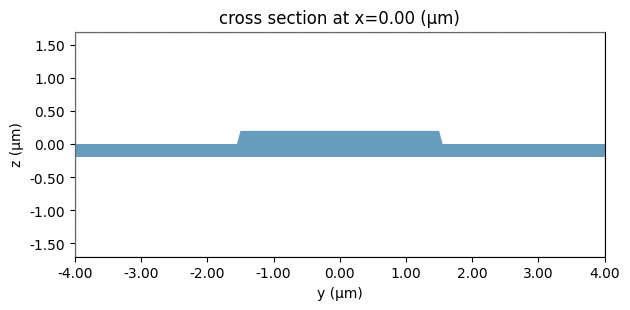

In [3]:
## Creating the ModeSolver

mode_spec = td.ModeSpec(num_modes=5, group_index_step=True)

plane_size = (0, sim_opt.bounding_box.size[1], sim_opt.bounding_box.size[2])
plane = sim_opt.bounding_box.updated_copy(size=plane_size)

mode_solver_opt = ModeSolver(simulation=sim_opt, freqs=[freq_opt], mode_spec=mode_spec, plane=plane)

_ = mode_solver_opt.plot()

In [4]:
mode_data_opt = web.run(mode_solver_opt, task_name="TFLN-opt_mode", folder_name="TFLN-VPI")

16:42:40 -03 Created task 'TFLN-opt_mode' with resource_id                      
             'mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=94428;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=870978;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\taskId]8;;\]8;id=94428;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\=]8;;\]8;id=973395;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\mo]8;;\]8;id=94428;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\-2fd6ccf9-bf00-]8;;\
             ]8;id=94428;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\4254-8a40-93319e87b10c']8;;\.

             Task folder: ]8;id=600642;https://tidy3d.simulation.cloud/folders/folder-8992deaf-7bd2-4439-9603-4a345bb23569\'TFLN-VPI']8;;\.

Output()

16:42:44 -03 Estimated FlexCredit cost: 0.004. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

             running solver

16:43:00 -03 status = success

             View simulation result at                                          
             ]8;id=249657;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=626342;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\taskId]8;;\]8;id=249657;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\=]8;;\]8;id=827206;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\mo]8;;\]8;id=249657;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\-2fd6ccf9-bf00-]8;;\
             ]8;id=249657;https://tidy3d.simulation.cloud/workbench?taskId=mo-2fd6ccf9-bf00-4254-8a40-93319e87b10c\4254-8a40-93319e87b10c']8;;\.

Output()

16:43:08 -03 loading simulation from simulation_data.hdf5

We can now visualize and inspect the optical modes. We are interested in the TE-like fundamental mode (with *mode_index == 0*), which has an effective index of 1.85 and a group index of 2.20. This information is very important to ensure velocity matching between the optical and RF modes, and hence optimize the electro-optical effect.

wavelength     n eff  k eff  TE (Ey) fraction  \
f            mode_index                                                  
1.934145e+14 0                 1.55  1.851449    0.0          0.999711   
             1                 1.55  1.813747    0.0          0.997992   
             2                 1.55  1.762851    0.0          0.004845   
             3                 1.55  1.753301    0.0          0.978658   
             4                 1.55  1.722364    0.0          0.030296   

                         wg TE fraction  wg TM fraction  mode area  \
f            mode_index                                              
1.934145e+14 0                 0.988385        0.869531   1.395676   
             1                 0.955486        0.874227   1.537450   
             2                 0.775261        0.987734   2.170106   
             3                 0.909164        0.881780   1.840836   
             4                 0.785301        0.951572   2.260011   

                         group index  dispersion (ps/(nm km))  
f            mode_index                                        
1.934145e+14 0              2.203290              -419.798243  
             1              2.235663              -341.654372  
             2              2.316117             -1372.697792  
             3              2.276735              -435.043857  
             4              2.346229             -1383.333042

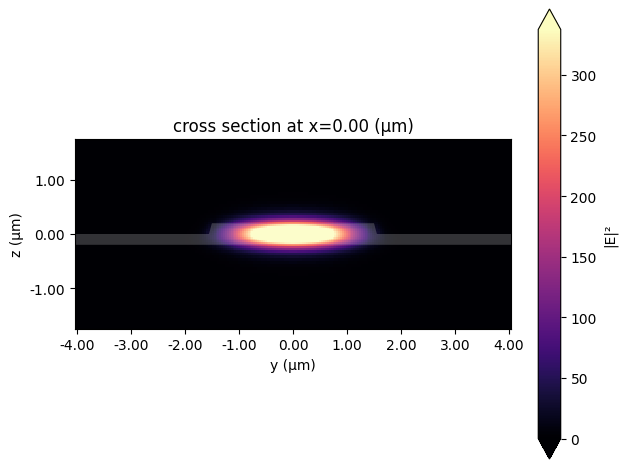

In [5]:
mode_solver_opt.plot_field("E", "abs^2", mode_index=0)
mode_data_opt.to_dataframe()

## RF CPW Transmission Line <a name="2"></a>

Next, we define the CPW geometry and again use [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) to calculate the RF mode.

For more information on CPW mode calculation, one can refer to [this](https://www.flexcompute.com/tidy3d/examples/notebooks/CPWRFPhotonics1/) example.

In [6]:
# RF frequency range
rf_freqs = np.linspace(1e9, 65e9, 20)

# RF materials
si_rf = td.Medium(permittivity=11.7)
sio2_rf = td.Medium(permittivity=3.9)
air_rf = td.Medium()
tfln_rf = td.AnisotropicMedium(
    xx=td.Medium(permittivity=44), yy=td.Medium(permittivity=27.9), zz=td.Medium(permittivity=44)
)
metal = td.LossyMetalMedium(
    frequency_range=(100000000.0, 100000000000.0),
    conductivity=41,
    fit_param=td.SurfaceImpedanceFitterParam(
        max_num_poles=16,
    ),
)

# Layer thickness and positioning parameters
tfln_thickness = 0.2
sio2_thickness = 7
metal_thickness = 0.9
tfln_height = (
    4.7 + tfln_thickness / 2
)  # Distance between the center of the TFLN from the Si substrate

# CPW geometry parameters
cpw_thickness = 0.9
cpw_center = sio2_thickness / 2 - cpw_thickness / 2
cpw_width = 10
cpw_gap = 4

# Define CPW transmission line structures
cpw_left = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -eff_inf, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, -cpw_width / 2 - cpw_gap, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

cpw_right = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, cpw_width / 2 + cpw_gap, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, eff_inf, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

cpw_center = td.Structure(
    geometry=td.Box.from_bounds(
        rmin=(-eff_inf, -cpw_width / 2, cpw_center - cpw_thickness / 2),
        rmax=(eff_inf, cpw_width / 2, cpw_center + cpw_thickness / 2),
    ),
    medium=metal,
)

# Define substrate and layer structures
sio2_slab = td.Structure(
    geometry=td.Box(center=(0, 0, 0), size=(eff_inf, eff_inf, sio2_thickness)), medium=sio2_rf
)
tfln_slab = td.Structure(
    geometry=td.Box(
        center=(0, 0, -sio2_thickness / 2 + tfln_height), size=(eff_inf, eff_inf, tfln_thickness)
    ),
    medium=tfln_rf,
)

si_substrate = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, -eff_inf), rmax=(eff_inf, eff_inf, -3.5)),
    medium=si_rf,
)

air_gap = td.Structure(
    geometry=td.Box.from_bounds(rmin=(-eff_inf, -eff_inf, 3.5), rmax=(eff_inf, eff_inf, eff_inf)),
    medium=air_rf,
)

Now we define the optical waveguide.

In [7]:
# Calculate vertical offset to position waveguides at TFLN slab level
delta_z = tfln_slab.geometry.center[2] - ridge.geometry.center[2]

# Define right waveguide positioned under CPW gap
waveguide_r = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="ridge_r",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="core_r",
        medium=tfln_rf,
    ),
]

# Define left waveguide positioned under CPW gap
waveguide_l = [
    ridge.updated_copy(
        geometry=ridge.geometry.translated(x=0, y=-cpw_width / 2 - cpw_gap / 2, z=delta_z),
        name="ridge_l",
        medium=tfln_rf,
    ),
    core.updated_copy(
        geometry=core.geometry.translated(x=0, y=cpw_width / 2 + cpw_gap / 2, z=delta_z),
        name="core_l",
        medium=tfln_rf,
    ),
]

### Grid Definition

Since the RF wavelength is much larger than the geometric features, we use a [LayerRefinementSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LayerRefinementSpec.html) at the CPW to automatically enhance the mesh and better resolve its corners.

For the rest of the simulation, we use the automatic grid with `min_steps_per_sim_size = 100`, which ensures at least 100 grid cells along the longest dimension of the simulation domain.

We will also add mesh override regions to properly resolve the thickness of the optical waveguide, as well as the gaps, to ensure accurate results.

In [8]:
# Define layer refinement specification for enhanced mesh at CPW corners
lr_spec = td.LayerRefinementSpec.from_structures(
    structures=[cpw_center, cpw_left, cpw_right],
    min_steps_along_axis=5,
    corner_refinement=td.GridRefinement(dl=cpw_thickness / 10, num_cells=5),
    refinement_inside_sim_only=False,
)


# Mesh override for waveguide region (fine mesh in z-direction)
override_region = td.MeshOverrideStructure(
    geometry=td.Box(
        size=(eff_inf, eff_inf, slab_thickness + core_thickness),
        center=(0, 0, tfln_slab.geometry.center[2] + tfln_thickness / 2),
    ),
    dl=(None, None, 0.01),
)

# Calculate gap center position
gap_center = cpw_center.geometry.center[1] + cpw_width / 2 + cpw_gap / 2

# Mesh override for left CPW gap (fine mesh in y-direction)
override_region_gap_l = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, gap_center, 0)),
    dl=(None, 0.01, None),
)

# Mesh override for right CPW gap (fine mesh in y-direction)
override_region_gap_r = td.MeshOverrideStructure(
    geometry=td.Box(size=(eff_inf, cpw_gap, eff_inf), center=(0, -gap_center, 0)),
    dl=(None, 0.01, None),
)

# Overall grid specification
grid_spec = td.GridSpec.auto(
    min_steps_per_sim_size=30,
    wavelength=td.C_0 / max(rf_freqs),
    layer_refinement_specs=[lr_spec],
    override_structures=[override_region, override_region_gap_l, override_region_gap_r],
)

For impedance calculation, we define a [current](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.CurrentIntegralAxisAligned.html) integration path around the CPW signal, and a [voltage](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.VoltageIntegralAxisAligned.html) integration path from the signal to ground.

In [9]:
# Define current integration path (loop around CPW signal)
I_int = mw.CurrentIntegralAxisAligned(
    center=cpw_center.geometry.center,
    size=(
        0,
        cpw_width + cpw_gap,
        5 * cpw_thickness,
    ),
    sign="+",
)

# Define voltage integration path (line from signal to ground)
V_int = mw.VoltageIntegralAxisAligned(
    center=(0, cpw_width / 2 + cpw_gap / 2, cpw_center.geometry.center[2]),
    size=(0, cpw_gap, 0),
    sign="-",
)

Finally, we can create the [Simulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Simulation.html) and [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) objects.

In [10]:
# Simulation domain size
sim_rf_size = (25, 138, 150)

# Create RF simulation
sim_vpi = td.Simulation(
    size=sim_rf_size,
    structures=[sio2_slab, si_substrate, air_gap, cpw_left, cpw_right, cpw_center]
    + waveguide_r
    + waveguide_l,
    grid_spec=grid_spec,
    run_time=1e-12,
)

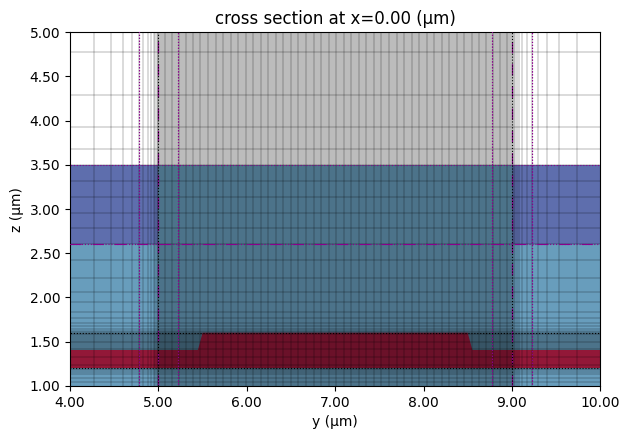

In [11]:
# Create and visualize the mode solver

plane = td.Box(
    center=cpw_center.geometry.center,
    size=(0, sim_vpi.size[1], sim_vpi.size[2]),
)

mzm_solver = ModeSolver(
    simulation=sim_vpi,
    plane=plane,
    mode_spec=td.ModeSpec(num_modes=1, target_neff=2.2),
    freqs=rf_freqs,
)

# Visualize the mesh

ax = mzm_solver.plot()
mzm_solver.plot_grid(ax=ax)
ax.set_ylim(1, 5)
ax.set_xlim(4, 10)
plt.show()

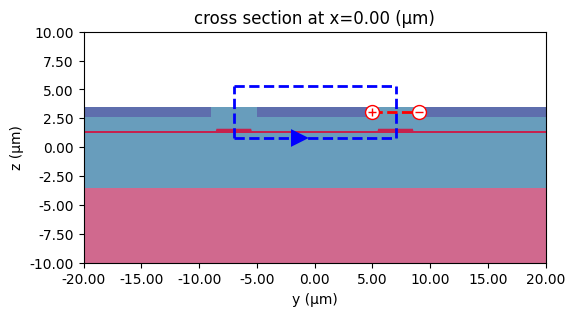

In [12]:
# Plot V and I integration paths
fig, ax = plt.subplots(figsize=(10, 3))
mzm_solver.plot(ax=ax)
I_int.plot(x=0, ax=ax)
V_int.plot(x=0, ax=ax)
ax.set_xlim(-20, 20)
ax.set_ylim(-10, 10)
plt.show()

In [13]:
mzm_mode_data = web.run(mzm_solver, task_name="MZM mode solver", path="data/MZM_mode_data.hdf5")

16:43:10 -03 Created task 'MZM mode solver' with resource_id                    
             'mo-083aec84-4655-4b4c-831a-b60d07f90466' and task_type            
             'MODE_SOLVER'.

             View task using web UI at                                          
             ]8;id=630299;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=975803;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\taskId]8;;\]8;id=630299;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\=]8;;\]8;id=877767;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\mo]8;;\]8;id=630299;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\-083aec84-4655-]8;;\
             ]8;id=630299;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\4b4c-831a-b60d07f90466']8;;\.

             Task folder: ]8;id=504119;https://tidy3d.simulation.cloud/folders/folder-f9e994c1-6315-4b44-af3a-c2cb1435b23a\'default']8;;\.

Output()

16:43:12 -03 Estimated FlexCredit cost: 0.016. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

...

16:43:22 -03 running solver

16:43:47 -03 status = success

             View simulation result at                                          
             ]8;id=549881;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=96522;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\taskId]8;;\]8;id=549881;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\=]8;;\]8;id=4286;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\mo]8;;\]8;id=549881;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\-083aec84-4655-]8;;\
             ]8;id=549881;https://tidy3d.simulation.cloud/workbench?taskId=mo-083aec84-4655-4b4c-831a-b60d07f90466\4b4c-831a-b60d07f90466']8;;\.

Output()

16:44:13 -03 loading simulation from data/MZM_mode_data.hdf5

Visualizing the results:

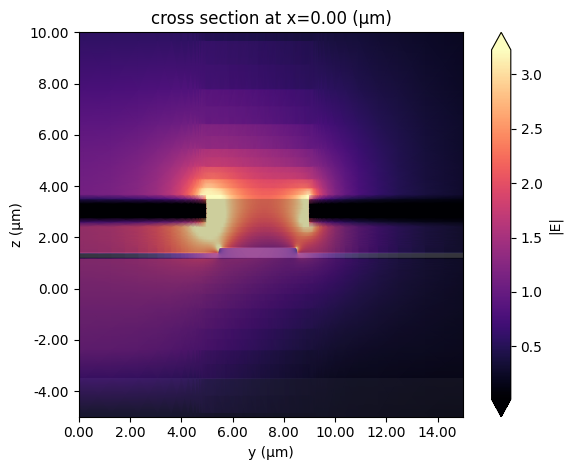

In [14]:
# Visualize the RF mode
ax = mzm_solver.plot_field("E", "abs", f=rf_freqs[0], mode_index=0, robust=True, shading="gouraud")
ax.set_xlim(0, 15)
ax.set_ylim(-5, 10)

plt.show()

We can now use the built-in [ImpedanceCalculator](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/microwave/_autosummary/tidy3d.plugins.microwave.ImpedanceCalculator.html) to calculate and visualize the impedance results.

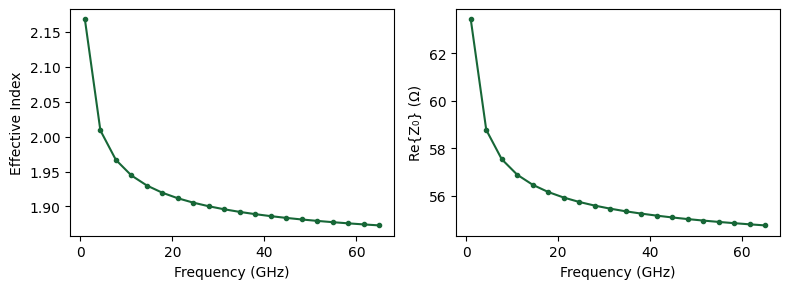

In [15]:
n_eff = mzm_solver.data.n_eff.isel(mode_index=0).values

# Calculate Z0
Z0_mzm = np.conjugate(
    mw.ImpedanceCalculator(voltage_integral=V_int, current_integral=I_int).compute_impedance(
        mzm_mode_data
    )
).squeeze()

fig, ax = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

ax[0].plot(rf_freqs * 1e-9, n_eff, ".-")
ax[0].set(ylabel="Effective Index", xlabel="Frequency (GHz)")

ax[1].plot(rf_freqs * 1e-9, np.real(Z0_mzm), ".-")
_ = ax[1].set(ylabel="Re{Z₀} (Ω)", xlabel="Frequency (GHz)")

## Computation of Vπ·L <a name="3"></a>

To calculate the Pockels effect, we apply an electric field along the LiNbO₃ cut direction to perturb the optical medium. First, we normalize the field by the applied voltage and shift its coordinates so they align with the optical simulation, where the dielectric waveguide is centered at y = 0.

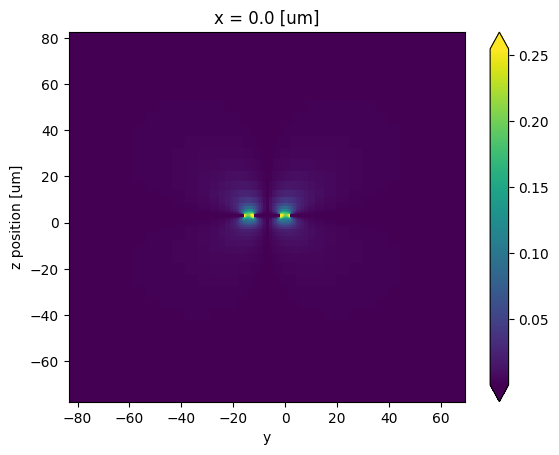

In [16]:
# Compute voltage across the gap and normalize electric field
v0 = V_int.compute_voltage(mzm_solver.data)
ey_norm = (mzm_solver.data.Ey / v0).isel(f=0, mode_index=0, drop=True).abs

# Shift coordinates to align with optical simulation (waveguide centered at y = 0)
offset = cpw_width / 2 + cpw_gap / 2
ey_norm = ey_norm.assign_coords(y=ey_norm.y - offset)

# Plot normalized electric field
_ = ey_norm.isel(x=0).transpose("z", "y").plot(robust=True)

The normalized electric field is applied to the LiNbO₃ crystal along its z-axis, following the Pockels effect model:


$$ \Delta_n = -0.5 n_e^3 r_{33} E $$


Where:
- $\Delta_n$: Index variation
- $n_e$: Extraordinary refractive index
- $r_{33}$: Pockels coefficient (30.9 pm/V) 
- $E$: Normalized electric field from CPW (1V across gap)

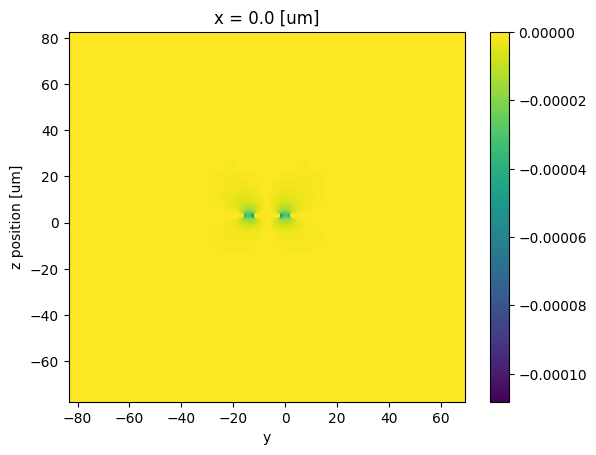

In [17]:
# Extract LiNbO3 material properties at optical wavelength
eps_o, eps_e, _ = (e.real for e in LiNbO3.eps_diagonal(td.C_0 / opt_wavelength))
n_e = eps_e**0.5
r33 = 30.9e-6  # Pockels coefficient in μm/V

# Calculate refractive index variation from Pockels effect
Δn = -0.5 * n_e**3 * r33 * ey_norm

# Plot index variation (perturbation will only take effect over the LiNbO₃ regions)
_ = Δn.isel(x=0).transpose("z", "y").plot(robust=False)

Now, assuming that the field scales with the applied voltage, we can define an auxiliary function to create the perturbed medium using a [CustomAnisotropicMedium](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.CustomAnisotropicMedium.html) object as a function of the voltage. 

This incorporates the index change due to the RF fields and returns a [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) object.

In [18]:
# Use a single data point for the homogeneous directions
eps_o_array = td.SpatialDataArray(np.full((1, 1, 1), eps_o), coords={"x": [0], "y": [0], "z": [0]})


def perturbed_solver(voltage):
    perturbed_ln = td.CustomAnisotropicMedium(
        xx=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
        yy=td.CustomMedium(permittivity=(n_e + voltage * Δn) ** 2, subpixel=True),
        zz=td.CustomMedium(permittivity=eps_o_array, subpixel=True),
    )
    perturbed_sim = sim_opt.updated_copy(
        structures=[core.updated_copy(medium=perturbed_ln), ridge.updated_copy(medium=perturbed_ln)]
    )
    ms = mode_solver_opt.updated_copy(simulation=perturbed_sim)
    return ms

Next, we create a [Batch](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.web.api.container.Batch.html) and run all mode simulations in parallel.

In [19]:
# Define voltages to apply and create a Batch of simulations
voltages = np.arange(5)
sims = {str(v): perturbed_solver(v) for v in voltages}

batch = web.Batch(simulations=sims, folder_name="perturbed_mode")

# Run all simulations in parallel
batch_data = batch.run(path_dir="batch_perturbed_mode")

Output()

16:44:22 -03 Started working on Batch containing 5 tasks.

16:44:29 -03 Maximum FlexCredit cost: 0.020 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

16:44:44 -03 Batch complete.

Output()

Finally, we can observe the variation of the waveguide mode effective index as a function of the applied voltage and calculate the Vπ·L figure of merit.

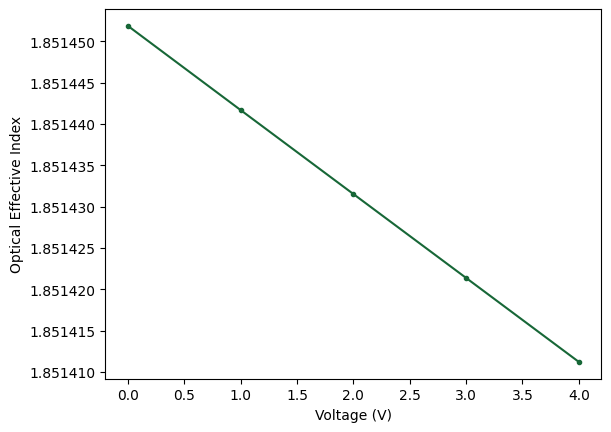

In [20]:
n_eff = [sim_data.n_eff.isel(mode_index=0, f=0).item() for sim_data in batch_data.values()]

_ = plt.plot(voltages, n_eff, ".-")
_ = plt.ticklabel_format(style="plain", useOffset=False)
plt.gca().set(xlabel="Voltage (V)", ylabel="Optical Effective Index")

plt.show()

In [21]:
# The variation is quite linear, so we simply use the largest interval
dneff_dV = abs(n_eff[-1] - n_eff[0]) / (voltages[-1] - voltages[0])

vpil = 0.5 * opt_wavelength / dneff_dV  # in V·μm"

print(f"Vπ·L (single-drive) = {vpil * 1e-4:.2f} V·cm")
print(f"Vπ·L (push-pull)    = {vpil * 1e-4 / 2:.2f} V·cm")

Vπ·L (single-drive) = 7.62 V·cm
Vπ·L (push-pull)    = 3.81 V·cm
